# 09: Threshold Optimization

## 1. Imports

In [17]:
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
)

from src.config import PROJECT_ROOT
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import (
    TRAIN_FEATURED_PATH,
    SPLIT_MANIFEST_PATH,
    RESULTS_DIR,
    TARGET,
    ID_COLUMN,
    RANDOM_STATE,
)

## 2. Load Dataset

In [18]:
featured = pd.read_csv(TRAIN_FEATURED_PATH)
manifest = pd.read_csv(SPLIT_MANIFEST_PATH)

train_ids = set(manifest.loc[manifest["Split"] == "train", ID_COLUMN])
holdout_ids = set(manifest.loc[manifest["Split"] == "test", ID_COLUMN])

development = (
    featured[featured[ID_COLUMN].isin(train_ids)]
    .sort_values(ID_COLUMN)
    .reset_index(drop=True)
)

holdout = (
    featured[featured[ID_COLUMN].isin(holdout_ids)]
    .sort_values(ID_COLUMN)
    .reset_index(drop=True)
)

X_dev = development.drop(columns=[TARGET, ID_COLUMN])
y_dev = development[TARGET]
X_holdout = holdout.drop(columns=[TARGET, ID_COLUMN])
y_holdout = holdout[TARGET]

print("Development rows:", len(development))
print("Holdout rows:", len(holdout))
print("Development attrition rate:", f"{y_dev.mean():.1%}")
print("Holdout attrition rate:", f"{y_holdout.mean():.1%}")

Development rows: 846
Holdout rows: 212
Development attrition rate: 16.9%
Holdout attrition rate: 17.0%


## 3. Build Pipeline

In [19]:
categorical_columns = [
    column for column in X_dev.columns
    if not pd.api.types.is_numeric_dtype(X_dev[column])
]

numeric_columns = [
    column for column in X_dev.columns
    if column not in categorical_columns
]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_columns),
    ("categorical", categorical_pipeline, categorical_columns),
])

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        C=0.03,
        l1_ratio=0.0,  # L2
        class_weight=None,
        solver="liblinear",
        max_iter=3000,
        random_state=RANDOM_STATE,
    )),
])

## 4. Generate Out-Of-Fold (OOF) Probabilities

In [20]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

oof_probability = cross_val_predict(
    logistic_model,
    X_dev,
    y_dev,
    cv=cv,
    method="predict_proba",
    n_jobs=-1,
)[:, 1]

print("OOF ROC-AUC:", round(roc_auc_score(y_dev, oof_probability), 4))
print("OOF PR-AUC:", round(average_precision_score(y_dev, oof_probability), 4))

OOF ROC-AUC: 0.8272
OOF PR-AUC: 0.6364


## 5. Scan Possible Thresholds

In [21]:
thresholds = np.arange(0.05, 0.951, 0.01)
rows = []

for threshold in thresholds:
    prediction = (oof_probability >= threshold).astype(int)

    rows.append({
        "threshold": threshold,
        "precision": precision_score(y_dev, prediction, zero_division=0),
        "recall": recall_score(y_dev, prediction, zero_division=0),
        "f1": f1_score(y_dev, prediction, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_dev, prediction),
        "accuracy": accuracy_score(y_dev, prediction),
    })

threshold_results = pd.DataFrame(rows)
threshold_results.head()

,threshold,precision,recall,f1,balanced_accuracy,accuracy
0,0.05,0.192686,0.958042,0.320843,0.570771,0.314421
1,0.06,0.201767,0.958042,0.333333,0.593530,0.352246
2,0.07,0.205837,0.937063,0.337531,0.600822,0.378251
3,0.08,0.219269,0.923077,0.354362,0.627257,0.431442
4,0.09,0.231579,0.923077,0.370266,0.650016,0.469267


## 6. Review Threshold Tradeoffs

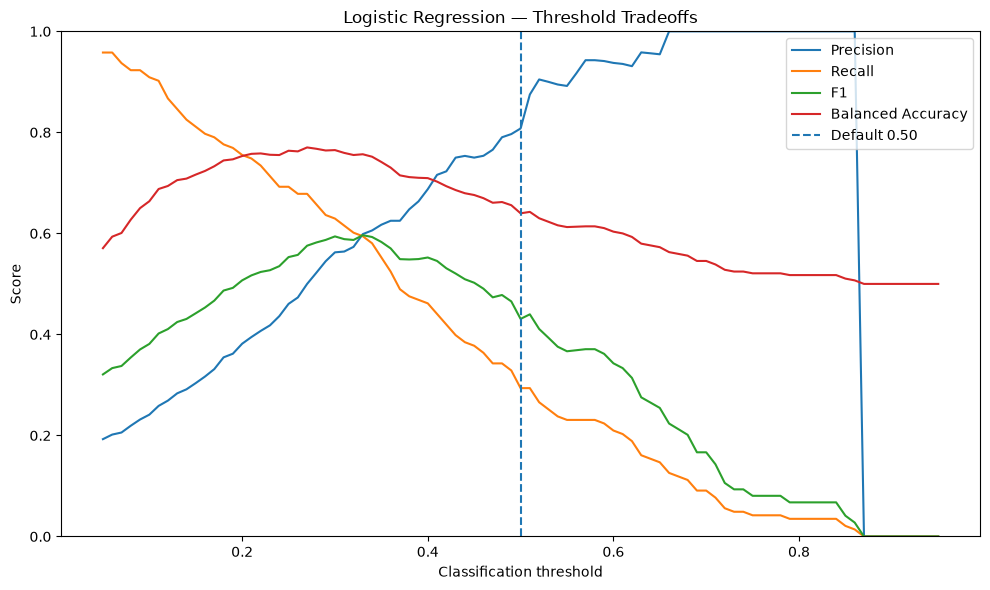

In [22]:
plt.figure(figsize=(10, 6))

for metric in ["precision", "recall", "f1", "balanced_accuracy"]:
    plt.plot(
        threshold_results["threshold"],
        threshold_results[metric],
        label=metric.replace("_", " ").title(),
    )

plt.axvline(0.50, linestyle="--", label="Default 0.50")
plt.xlabel("Classification threshold")
plt.ylabel("Score")
plt.title("Logistic Regression — Threshold Tradeoffs")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

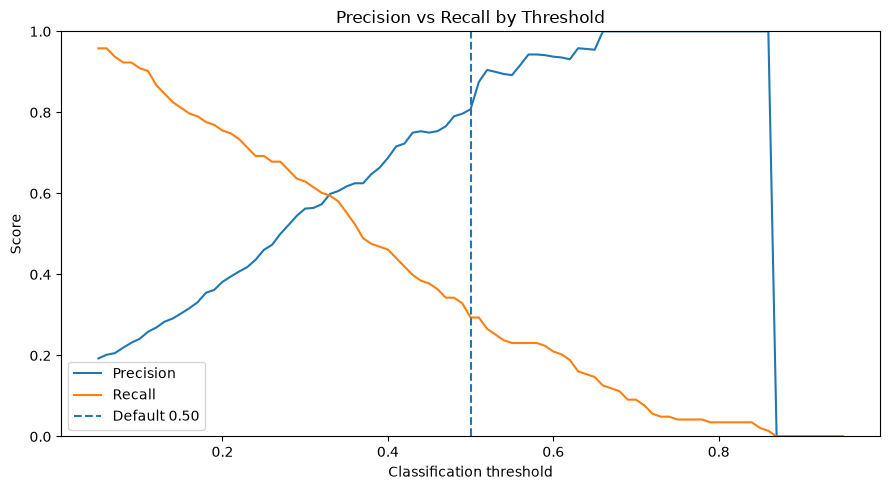

In [23]:
plt.figure(figsize=(9, 5))
plt.plot(threshold_results["threshold"], threshold_results["precision"], label="Precision")
plt.plot(threshold_results["threshold"], threshold_results["recall"], label="Recall")
plt.axvline(0.50, linestyle="--", label="Default 0.50")
plt.xlabel("Classification threshold")
plt.ylabel("Score")
plt.title("Precision vs Recall by Threshold")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

## 7. Candidate operating points

We compare several defensible choices:

- **Default 0.50**
- **Max F1**: balances precision and recall for the positive class
- **Max balanced accuracy**: balances sensitivity to both classes
- **Recall ≥ 60% with best precision**: emphasizes finding more attrition cases

For this project, **Max F1** is used as the primary selected threshold because our evaluation is centered on the uncommon positive class and PR-focused metrics.

In [24]:
best_f1_row = threshold_results.loc[threshold_results["f1"].idxmax()].copy()
best_balanced_row = threshold_results.loc[
    threshold_results["balanced_accuracy"].idxmax()
].copy()

recall_candidates = threshold_results[
    threshold_results["recall"] >= 0.60
].copy()

high_recall_row = (
    recall_candidates
    .sort_values(["precision", "f1"], ascending=False)
    .iloc[0]
    .copy()
)

default_row = threshold_results.iloc[
    (threshold_results["threshold"] - 0.50).abs().argsort()[:1]
].iloc[0]

candidate_thresholds = pd.DataFrame([
    {"strategy": "Default 0.50", **default_row.to_dict()},
    {"strategy": "Max F1", **best_f1_row.to_dict()},
    {"strategy": "Max balanced accuracy", **best_balanced_row.to_dict()},
    {"strategy": "Recall >= 60% with best precision", **high_recall_row.to_dict()},
])

candidate_thresholds.round(4)

,strategy,threshold,precision,recall,f1,balanced_accuracy,accuracy
0,Default 0.50,0.50,0.8077,0.2937,0.4308,0.6397,0.8688
1,Max F1,0.33,0.5986,0.5944,0.5965,0.7567,0.8641
2,Max balanced accuracy,0.27,0.5000,0.6783,0.5757,0.7702,0.8310
3,Recall >= 60% with best precision,0.32,0.5733,0.6014,0.5870,0.7552,0.8570


In [25]:
selected_threshold = float(best_f1_row["threshold"])
print("Selected threshold:", round(selected_threshold, 2))

Selected threshold: 0.33


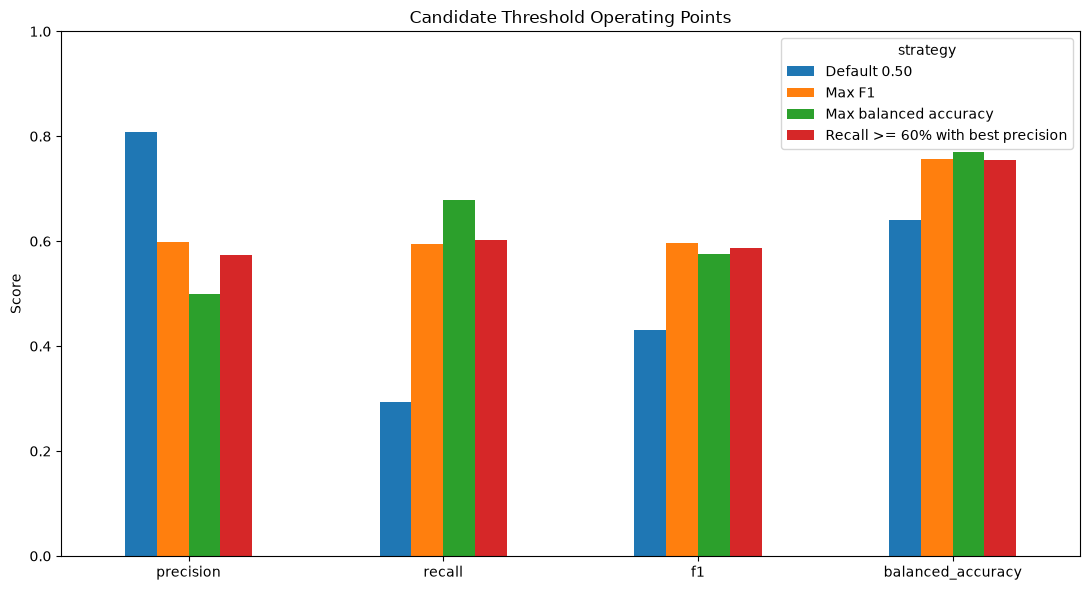

In [26]:
candidate_thresholds.set_index("strategy")[[
    "precision", "recall", "f1", "balanced_accuracy"
]].T.plot(
    kind="bar",
    figsize=(11, 6),
)

plt.title("Candidate Threshold Operating Points")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 8. OOF Precision–Recall curve

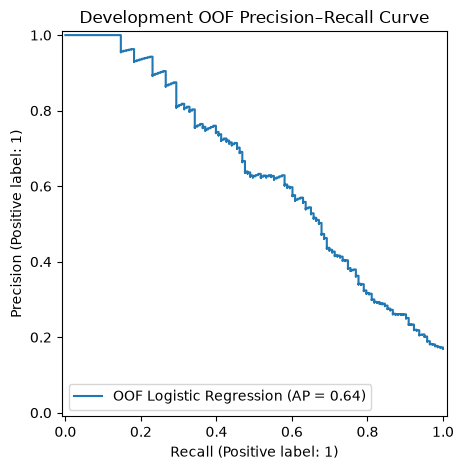

In [27]:
PrecisionRecallDisplay.from_predictions(
    y_dev,
    oof_probability,
    name="OOF Logistic Regression",
)
plt.title("Development OOF Precision–Recall Curve")
plt.tight_layout()
plt.show()

## 9. Train

In [28]:
logistic_model.fit(X_dev, y_dev)

holdout_probability = logistic_model.predict_proba(X_holdout)[:, 1]
holdout_pred_default = (holdout_probability >= 0.50).astype(int)
holdout_pred_selected = (holdout_probability >= selected_threshold).astype(int)

## 10. Evaluation

In [29]:
def threshold_metrics(y_true, y_probability, y_prediction, label, threshold):
    return {
        "strategy": label,
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_prediction),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_prediction),
        "precision": precision_score(y_true, y_prediction, zero_division=0),
        "recall": recall_score(y_true, y_prediction, zero_division=0),
        "f1": f1_score(y_true, y_prediction, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_probability),
        "pr_auc": average_precision_score(y_true, y_probability),
        "brier_score": brier_score_loss(y_true, y_probability),
    }

holdout_comparison = pd.DataFrame([
    threshold_metrics(
        y_holdout, holdout_probability, holdout_pred_default,
        "Default 0.50", 0.50,
    ),
    threshold_metrics(
        y_holdout, holdout_probability, holdout_pred_selected,
        "OOF-selected threshold", selected_threshold,
    ),
])

holdout_comparison.round(4)

,strategy,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,brier_score
0,Default 0.50,0.50,0.8538,0.6136,0.6923,0.2500,0.3673,0.8278,0.5489,0.1087
1,OOF-selected threshold,0.33,0.8349,0.7459,0.5116,0.6111,0.5570,0.8278,0.5489,0.1087


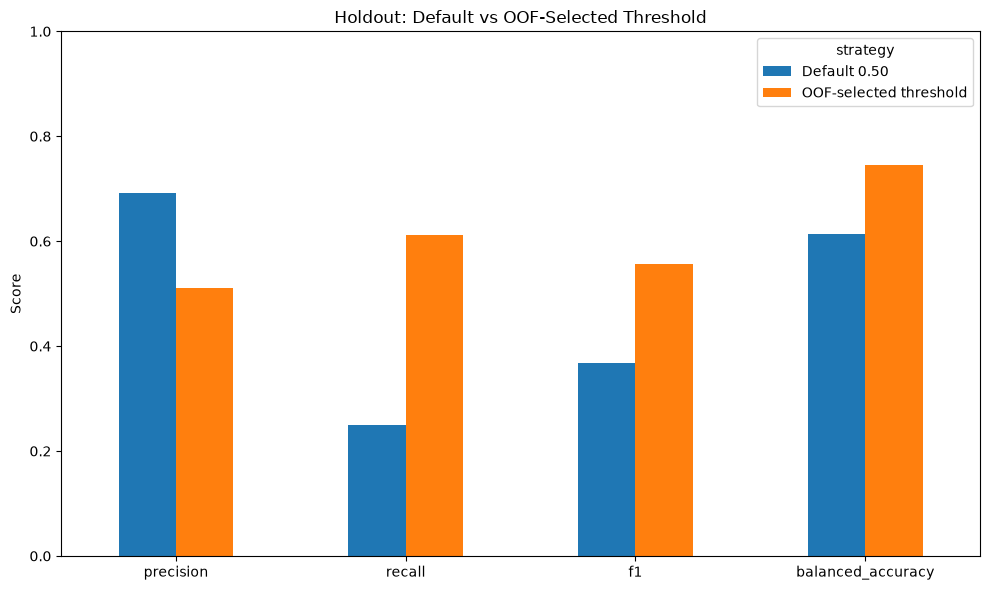

In [30]:
holdout_comparison.set_index("strategy")[[
    "precision", "recall", "f1", "balanced_accuracy"
]].T.plot(
    kind="bar",
    figsize=(10, 6),
)

plt.title("Holdout: Default vs OOF-Selected Threshold")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 11. Confusion Matrices

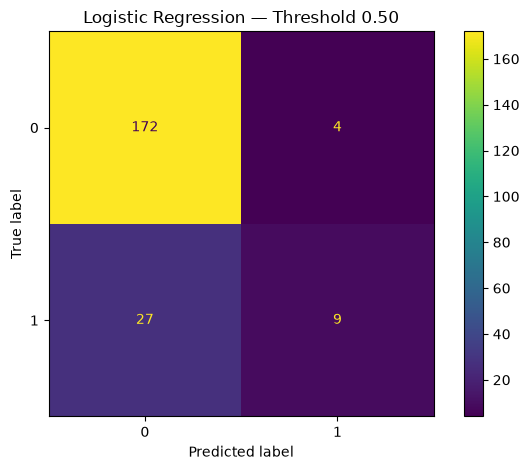

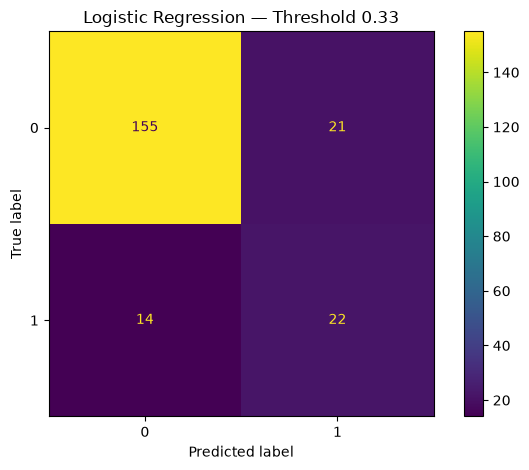

In [31]:
ConfusionMatrixDisplay.from_predictions(
    y_holdout,
    holdout_pred_default,
)
plt.title("Logistic Regression — Threshold 0.50")
plt.tight_layout()
plt.show()

ConfusionMatrixDisplay.from_predictions(
    y_holdout,
    holdout_pred_selected,
)
plt.title(f"Logistic Regression — Threshold {selected_threshold:.2f}")
plt.tight_layout()
plt.show()

 ## 12. Save

In [32]:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

threshold_results.to_csv(RESULTS_DIR / "logistic_threshold_scan.csv", index=False)
candidate_thresholds.to_csv(RESULTS_DIR / "logistic_threshold_candidates.csv", index=False)

pd.DataFrame({
    ID_COLUMN: development[ID_COLUMN].values,
    "Actual": y_dev.values,
    "OOF_AttritionProbability": oof_probability,
}).to_csv(RESULTS_DIR / "logistic_oof_predictions.csv", index=False)

holdout_comparison.to_csv(
    RESULTS_DIR / "logistic_threshold_holdout_comparison.csv",
    index=False,
)

pd.DataFrame({
    ID_COLUMN: holdout[ID_COLUMN].values,
    "Actual": y_holdout.values,
    "AttritionProbability": holdout_probability,
    "Prediction_Default_050": holdout_pred_default,
    "Prediction_OOF_Selected": holdout_pred_selected,
}).to_csv(
    RESULTS_DIR / "logistic_threshold_holdout_predictions.csv",
    index=False,
)

print("Saved threshold analysis to:", RESULTS_DIR)

Saved threshold analysis to: C:\Users\jeffh\PycharmProjects\employee-attrition\results
